# Problema:


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot
import warnings
import numpy as np

warnings.filterwarnings("ignore")

# import os
# os.getcwd()
# os.chdir('C:\\Users\\saulim\\Documents\\Python Proyectos\\Jupyter notebook\\
#           3- Aprendizaje de máquina supervisado\\M25- Regresión Logística')

BD_drugs = pd.read_csv("drugs.csv")
BD_drugs.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## Cargue la base de datos “drugs.csv” en Python e investigue cómo convertir las variables predictoras cualitativas de esta base a una escala numérica mediante la instrucción “preprocessing.LabelEncoder()”.
## Por ejemplo, si una variable tiene 3 posibles categorías, deberá cambiar sus resultados a 0, 1 o 2.

In [3]:
# Columnas de entradas
feature_cols = ["Age","Sex", "BP", "Cholesterol", "Na_to_K"]

X = BD_drugs[feature_cols].values

#Columnas de salidas
y = BD_drugs.Drug

#Preprosesamiento para generar El label encoder
from sklearn import preprocessing

Cod_Sex = preprocessing.LabelEncoder()
Cod_BP = preprocessing.LabelEncoder()
Cod_Cholesterol = preprocessing.LabelEncoder()

Cod_Sex.fit(["M", "F"])                # 1 = Male , 0= Female 
Cod_BP.fit(["NORMAL", "LOW", "HIGH"])                 # 2= Normal, 1=LOW, 0=High
Cod_Cholesterol.fit(["NORMAL", "HIGH"])        # 1= Normal, 0=High

X[:,1] = Cod_Sex.transform(X[:,1])
X[:,2] = Cod_BP.transform(X[:,2])
X[:,3] = Cod_Cholesterol.transform(X[:,3])

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [4]:
def NacInt(Variable):
    import math
    if Variable == 'drugA' or Variable == "drugB" or Variable == "drugC":
        return 0 # 0 = Nacional
    elif Variable == 'drugY' or Variable == 'drugX':
        return 1 # 1 = InterNacional
    else:
        return math.nan

y_IN = y.apply(NacInt)
y_IN

0      1
1      0
2      0
3      1
4      1
      ..
195    0
196    0
197    1
198    1
199    1
Name: Drug, Length: 200, dtype: int64

## Use los diversos métodos de optimización para una Regresión Logística vistos en este módulo para encontrar un algoritmo óptimo de clasificación. 
### Explique cuál sería su recomendación para este caso. Regresión Logística 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Sag: Stochacstic Average Gradient
# newton-cg: Newton
# liblinear: Library for large linear Classification (Algoritmo coordinante descendente)
# saga: Variante del método sag
# lblfgs: Limited-memory Broyden-Fletcher-Goldfarb-Shannon Algorithm
Modelos_Reg_Log = ("sag", "newton-cg", "liblinear", "saga", "lbfgs")

# Creación de las bases de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size= 0.2, random_state= 23)

In [7]:
def LogReg_ScoreAndClassRept (MODELO, x_train, x_test, y_train, y_test):
    print("REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver): ", MODELO)
    model = LogisticRegression(solver = MODELO)
    clf = model.fit(x_train, y_train)
    
    #Prediccion de etiquetas de clase sobre datos de prueba
    y_pred = model.predict(x_test)
    
    # Impresion de coeficientes de la regresion de puntas
    print("Intercepto (Beta 0): ", clf.intercept_)
    print("Pesos de cada variable (Beta1, Beta2, ..., Beta4): ", clf.coef_)
    
    print("-------------------------------------------------------------------------------------------------- ")
    # Evaluacion de la presicion del modelo
    score = model.score(x_test, y_test)
    print("Precisión global: ", score)
    
    print("-------------------------------------------------------------------------------------------------- ")
    # Reporte de clasificacion
    print(classification_report(y_test, y_pred))
    print("-------------------------------------------------------------------------------------------------- ")
    print(" ")
    

In [13]:
def LogReg_Score(MODELO, x_train, x_test, y_train, y_test):
    model = LogisticRegression(solver = MODELO)
    clf = model.fit(x_train, y_train)

    #Prediccion de etiquetas de clase sobre datos de prueba
    y_pred = model.predict(x_test)

    # Evaluacion de la presicion del modelo
    score = model.score(x_test, y_test)
    return score

In [15]:
for i in Modelos_Reg_Log:
    LogReg_ScoreAndClassRept(i, X_train, X_test, Y_train, Y_test)



REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver):  sag
Intercepto (Beta 0):  [ 0.22997712 -0.07768444  0.07789589  0.27994725 -0.51013582]
Pesos de cada variable (Beta1, Beta2, ..., Beta4):  [[-0.02826965  0.17266816 -0.62550338  0.11190691  0.10116186]
 [ 0.0625167  -0.08931826 -0.68072199 -0.02543128 -0.23090593]
 [ 0.01309209  0.06400805  0.15103453 -0.32365127 -0.07919295]
 [ 0.00592898  0.01892381  1.2706403   0.50761215 -0.10947392]
 [-0.05326812 -0.16628176 -0.11544946 -0.27043652  0.31841095]]
-------------------------------------------------------------------------------------------------- 
Precisión global:  0.75
-------------------------------------------------------------------------------------------------- 
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         5
       drugB       0.00      0.00      0.00         0
       drugC       0.00      0.00      0.00         3
       drugX       0.86      0.92      0.89        13
 

In [17]:
for i in Modelos_Reg_Log:
    print("Puntuacion Modelo",i, ": ", end='')
    print(LogReg_Score(i, X_train, X_test, Y_train, Y_test))
    print(" ")

Puntuacion Modelo sag : 0.75
 
Puntuacion Modelo newton-cg : 0.975
 
Puntuacion Modelo liblinear : 0.85
 
Puntuacion Modelo saga : 0.725
 
Puntuacion Modelo lbfgs : 0.85
 


### Explique cuál sería su recomendación para este caso. Regresión Logística

Según lo visto en los distintos modelos de regresión logística el mejor fue el de NEWTON CG que por muy raro que parezca, este tuvo una precisión del 97.5% (con los datos de prueba planteado, se había obtenido un 100% pero de perdió la semilla), lo curioso es que casi todos los modelos tenían una precisión predicción del 50% o mayor para la mayoría de medicinas. Lo que muestra que anqué los modelos sean "decentes" el modelo que no baja del 95% sin importar cuantas muestras aleatorias se colocaran, era el modelo newton-cg.

### Regresión Logística NEWTON CG 

In [21]:
# Creación de las bases de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, y_IN, test_size= 0.2, random_state= 23)

In [23]:
def LogReg_MapaCalor (MODELO, x_train, x_test, y_train, y_test):
    from sklearn.metrics import confusion_matrix
    
    print("REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver): ", MODELO)
    model = LogisticRegression(solver = MODELO)
    clf = model.fit(x_train, y_train)
    
    #Prediccion de etiquetas de clase sobre datos de prueba
    y_pred = model.predict(x_test)

    # Matriz de confusión 
    Matriz_Confusion = confusion_matrix(y_test, y_pred)

    # Etiquetas = sorted(list(set(y_IN)))
    Etiquetas = ["Nacional", "Internacional"]
    # Visualización de la matriz de confusion
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    f, ax = plt.subplots(figsize = (5,5))
    sns.heatmap(Matriz_Confusion,xticklabels = Etiquetas, yticklabels = Etiquetas,
                annot = True, linewidths = 0.5, linecolor = "red", fmt= ".0f", ax = ax)
   
    plt.xlabel("Medicina pronosticada")
    plt.ylabel("Medicina real")
    plt.show()

REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver):  newton-cg
Intercepto (Beta 0):  [-11.27968908]
Pesos de cada variable (Beta1, Beta2, ..., Beta4):  [[2.58385867e-04 1.46984865e-01 3.31605978e+00 2.05608508e+00
  6.67094649e-01]]
-------------------------------------------------------------------------------------------------- 
Precisión global:  0.975
-------------------------------------------------------------------------------------------------- 
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.97      1.00      0.98        32

    accuracy                           0.97        40
   macro avg       0.98      0.94      0.96        40
weighted avg       0.98      0.97      0.97        40

-------------------------------------------------------------------------------------------------- 
 
REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver):  newton-cg


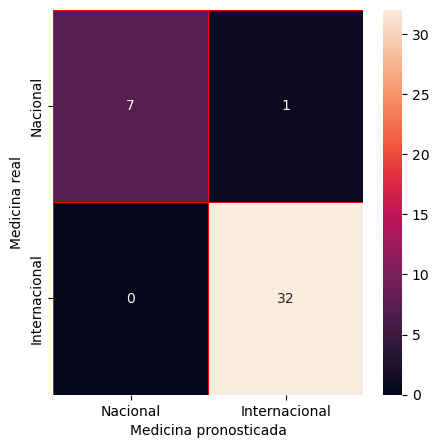

In [25]:
LogReg_ScoreAndClassRept("newton-cg", X_train, X_test, Y_train, Y_test)
LogReg_MapaCalor("newton-cg", X_train, X_test, Y_train, Y_test)

In [26]:

def LogReg_ROC (MODELO, x_train, x_test, y_train, y_test):
    print("REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver): ", MODELO)
    
    # Graficación de la curva ROC y cálculo del área bajo ella
    from sklearn.metrics import roc_curve
    from sklearn.metrics import roc_auc_score
    
    model = LogisticRegression(solver = MODELO)
    clf = model.fit(x_train, y_train)

    y_pred_probs = clf.predict_proba(x_test)[:,1]
    y_pred_probs = np.round(y_pred_probs, 0)

    y_test2 = y_test.to_numpy()
    y_test2 = [int(numeric_string) for numeric_string in y_test2]

    fpr, tpr, thresholds = roc_curve(y_test2, y_pred_probs)
    auc = roc_auc_score(y_test2, y_pred_probs)

    import matplotlib.pyplot as plt
    plt.plot([0,1],[0,1], "k--", color="red")
    plt.plot(fpr, tpr, marker=".", label = "Curva ROC (area = %0.2f): " % auc)
    plt.xlabel("Tasa de Falsos positivos")     # False positive Rates
    plt.ylabel("Tasa de verdaderos poitivos")  # True positive Rates
    plt.legend(loc="lower right")
    plt.title("Curva ROC  para refreseión logistica")


REGRESIÓN LOGÍSTICA CON SOLUCIONADOR (Solver):  newton-cg


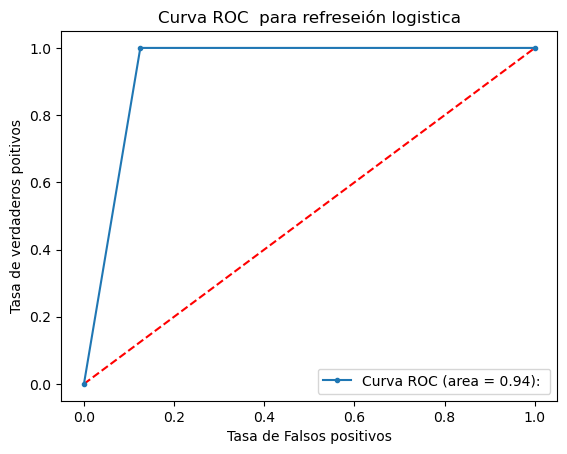

In [29]:
LogReg_ROC("newton-cg", X_train, X_test, Y_train, Y_test)

### ¿Qué tan eficaz es el algoritmo predictivo escogido? 
### Explique a detalle comentando sobre los indicadores obtenidos mediante el reporte de clasificación correspondiente y la curva ROC.

Este modelo fue el que presento las mejores predicciones presentando (en Macro) una precisión del 98%, un recall del 94% y una F1 Score del 96%, de entre todos los modelos generados, este fue el modelo con la mejor predictibilidad, aun con un rango de mejora, además de que al final del proceso se utilizó la variable de Nacionales e Internacionales lo que permitió hacer la curva de ROC, pero en dado caso que se hubiera requerido hacer otra curva de ROC multi-variable estas, tendrían un comportamiento casi idéntico aunque bajando la Macro Score F1 al 93% (si se usa el modelo con 5 posibles resultados).